In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import tensorflow as tf

In [ ]:
from keras.layers import Input,Dense,Flatten
from keras.models import Model
from keras.optimizers import Adam
from keras.preprocessing import image
import numpy as np
import glob
import keras
from keras import layers
from keras.preprocessing.image import ImageDataGenerator
import warnings
warnings.filterwarnings('ignore',category=FutureWarning)
from datetime import datetime
from keras.callbacks import ModelCheckpoint
from keras import applications



In [ ]:
# Define the image size
IMAGE_SIZE = [224, 224, 3]

In [ ]:
train_path = '/content/drive/Othercomputers/My Laptop/RoadImagesDataSet/Train'
test_path = '/content/drive/Othercomputers/My Laptop/RoadImagesDataSet/Test'

In [ ]:


train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)


# Train data
train_set = train_datagen.flow_from_directory(train_path,
                                              target_size=(224, 224),
                                              batch_size=64,
                                              class_mode='categorical')

# Test data
test_set = test_datagen.flow_from_directory(test_path,
                                            target_size=(224, 224),
                                            batch_size=64,
                                            class_mode='categorical')

Found 6300 images belonging to 7 classes.
Found 1580 images belonging to 7 classes.


In [ ]:
# Accessing class labels for the training data
train_class_labels = train_set.class_indices
print("Training class labels:", train_class_labels)

# Accessing class labels for the validation data
validation_class_labels = test_set.class_indices
print("Validation class labels:", validation_class_labels)

Training class labels: {'CementTiles': 0, 'ManHole': 1, 'PotHoles': 2, 'SandDirt': 3, 'SolidWaste': 4, 'SpeedBreaker': 5, 'WaterFilledPotholes': 6}
Validation class labels: {'CementTiles': 0, 'ManHole': 1, 'PotHoles': 2, 'SandDirt': 3, 'SolidWaste': 4, 'SpeedBreaker': 5, 'WaterFilledPotholes': 6}


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Define the Sequential model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    layers.MaxPooling2D(2, 2),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Dropout(0.25),

    layers.Flatten(),

    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(7, activation='softmax')  # Softmax activation for multi-class classification
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Print the model summary to check the output shapes
model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 222, 222, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 111, 111, 32)      0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 111, 111, 32)      0         
                                                                 
 conv2d_1 (Conv2D)           (None, 109, 109, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 54, 54, 64)        0         
 g2D)                                                            
                                                                 
 dropout_1 (Dropout)         (None, 54, 54, 64)        0

In [ ]:
batch = 64
train_steps = np.ceil(train_set.samples / batch)
validation_steps_per_epoch = np.ceil(test_set.samples / batch)
print(train_steps, validation_steps_per_epoch)

99.0 25.0


In [ ]:
# Define the file name for the model checkpoint
checkpoint_filepath = '/content/drive/MyDrive/Models/mycnn.keras'

# Define the ModelCheckpoint callback
checkpoint = ModelCheckpoint(filepath=checkpoint_filepath, verbose=1, save_best_only=True)

callbacks = [checkpoint]

model_history = model.fit(train_set,
                          validation_data=test_set,
                          epochs=10,
                          steps_per_epoch=99,
                          validation_steps=25,
                          callbacks=callbacks)

Epoch 1/10
99/99 [==============================] - ETA: 0s - loss: 2.6449 - accuracy: 0.2632 
Epoch 1: val_loss improved from inf to 1.79261, saving model to /content/drive/MyDrive/Models/mycnn.keras
99/99 [==============================] - 7168s 72s/step - loss: 2.6449 - accuracy: 0.2632 - val_loss: 1.7926 - val_accuracy: 0.3013
Epoch 2/10
99/99 [==============================] - ETA: 0s - loss: 1.6050 - accuracy: 0.3746
Epoch 2: val_loss did not improve from 1.79261
99/99 [==============================] - 509s 5s/step - loss: 1.6050 - accuracy: 0.3746 - val_loss: 2.0556 - val_accuracy: 0.3101
Epoch 3/10
99/99 [==============================] - ETA: 0s - loss: 1.4352 - accuracy: 0.4546
Epoch 3: val_loss did not improve from 1.79261
99/99 [==============================] - 576s 6s/step - loss: 1.4352 - accuracy: 0.4546 - val_loss: 2.0128 - val_accuracy: 0.3437
Epoch 4/10
99/99 [==============================] - ETA: 0s - loss: 1.2348 - accuracy: 0.5302
Epoch 4: val_loss improved from

KeyboardInterrupt: 

In [ ]:
model.save('my_cnn.h5')

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [ ]:
!ls /content/drive/My\ Drive/


In [ ]:
from tensorflow.keras.models import load_model

# Load the model
model2 = load_model('/content/drive/MyDrive/Models/mycnn.keras')

In [ ]:
# Define the file name for the model checkpoint
checkpoint_filepath = '/content/drive/MyDrive/Models/mycnn.keras'

# Define the ModelCheckpoint callback
checkpoint = ModelCheckpoint(filepath=checkpoint_filepath, verbose=1, save_best_only=True)

callbacks = [checkpoint]

model_history2 = model2.fit(train_set,
                          validation_data=test_set,
                          epochs=5,
                          steps_per_epoch=197,
                          validation_steps=50,
                            callbacks=callbacks)

Epoch 1/5
197/197 [==============================] - 580s 3s/step - loss: 0.2652 - accuracy: 0.9113 - val_loss: 0.9032 - val_accuracy: 0.7405
Epoch 2/5
197/197 [==============================] - 495s 3s/step - loss: 0.1999 - accuracy: 0.9313 - val_loss: 0.8117 - val_accuracy: 0.7709
Epoch 3/5
197/197 [==============================] - 468s 2s/step - loss: 0.2024 - accuracy: 0.9313 - val_loss: 1.0338 - val_accuracy: 0.7304
Epoch 4/5
197/197 [==============================] - 507s 3s/step - loss: 0.2220 - accuracy: 0.9348 - val_loss: 1.1660 - val_accuracy: 0.7082
Epoch 5/5
197/197 [==============================] - 505s 3s/step - loss: 0.1191 - accuracy: 0.9608 - val_loss: 1.1866 - val_accuracy: 0.7335


In [1]:
from keras.models import load_model
model = load_model("/content/drive/MyDrive/Models/mycnn.keras")


In [ ]:
import os

# Replace 'path_to_your_directory' with the actual path to your directory
directory_path = '/content/drive/Othercomputers/My Laptop/RoadImagesDataSet/Test'

# Get all folder names in the directory
class_labels= [f for f in os.listdir(directory_path) if os.path.isdir(os.path.join(directory_path, f))]

print(class_labels)

['ManHole', 'CementTiles', 'SolidWaste', 'SandDirt', 'SpeedBreaker', 'WaterFilledPotholes', 'PotHoles']


In [ ]:
test_path=directory_path

In [ ]:
model=model2

In [ ]:
from keras.preprocessing import image
from keras.applications.imagenet_utils import decode_predictions
import numpy as np

your_directory = test_path
y_true=[]
y_pred=[]
for root, dirs, files in os.walk(your_directory):
    for file in files:
      img_path=os.path.join(root, file)

      remove=your_directory+'/'
      orginal_label=root.replace(remove,"")
      y_true.append(orginal_label)

      # Load and preprocess the image
      img = image.load_img(img_path, target_size=(224, 224))  # Replace target size with your model's expected input size
      img_array = image.img_to_array(img)
      img_array = np.expand_dims(img_array, axis=0)

      # Predict the class probabilities
      probabilities = model.predict(img_array)

      # Get the index of the class with the highest probability
      predicted_index = np.argmax(probabilities)

      # Get the name of the class
      predicted_class = class_labels[predicted_index]
      y_pred.append(predicted_class)



print(y_true)
print(y_pred)

1/1 [==============================] - 0s 95ms/step
['ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', '

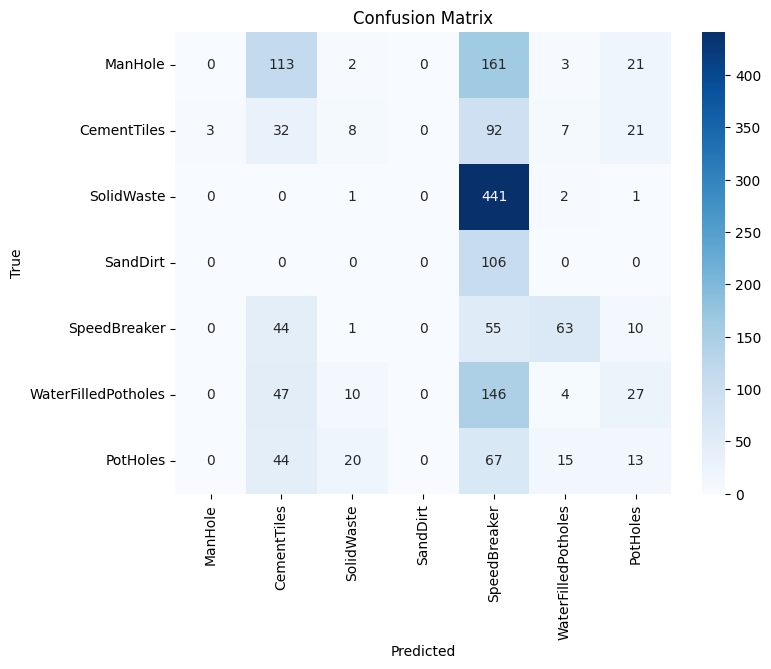

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn import metrics

# Assuming you have the true labels and predicted labels
true_labels = y_true# Replace with the true labels from your test set
predicted_labels =y_pred # Replace with the predicted labels from your model

# Create the confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='g', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_true,y_pred))

                     precision    recall  f1-score   support

        CementTiles       0.00      0.00      0.00       300
            ManHole       0.11      0.20      0.14       163
           PotHoles       0.02      0.00      0.00       445
           SandDirt       0.00      0.00      0.00       106
         SolidWaste       0.05      0.32      0.09       173
       SpeedBreaker       0.04      0.02      0.02       234
WaterFilledPotholes       0.14      0.08      0.10       159

           accuracy                           0.07      1580
          macro avg       0.05      0.09      0.05      1580
       weighted avg       0.04      0.07      0.04      1580



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [2]:
!pip install visualkeras

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 993.8/993.8 kB 11.5 MB/s eta 0:00:00


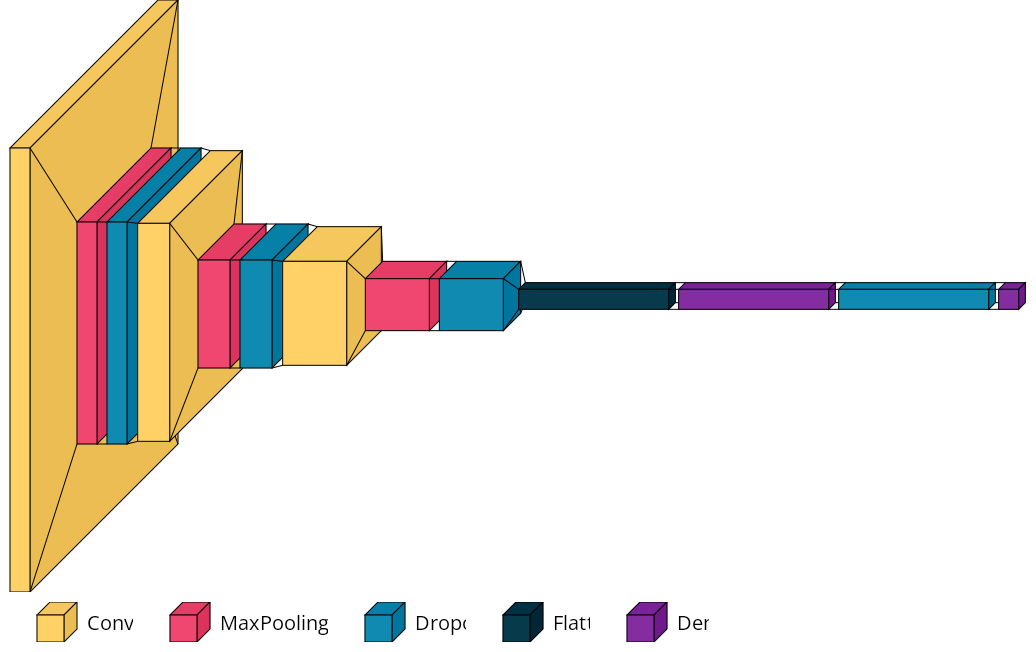

In [24]:
import visualkeras
from PIL import ImageFont

font = ImageFont.truetype("/content/drive/Othercomputers/My Laptop/RoadImagesDataSet/OpenSans-Regular.ttf", 20)
visualkeras.layered_view(model, legend=True,scale_xy=2, scale_z=0.5, max_z=150,font=font,to_file='/content/drive/Othercomputers/My Laptop/RoadImagesDataSet/output.png') # font is optional!